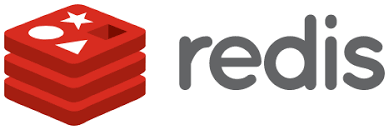

# Introduction

Sur la base du langage python, vous traiterez un cas d'utilisation de Redis pour les applications Web. 

Votre objectif est de créer une application performante en mettant en place des caches de données sous Redis et en assurant la gestion du cache.


## Prérequis

* Vérifier que Docker desktop est bien démarré
* Ouvrer un terminal ssh
* A partir du terminal, positionnez vous dans le répertoire architecture_distribuée/docker.
  

Démarrer votre container redis :

Vérifiez que votre container mongo est opérationnel :

Pour ce TP, votre machine devra disposer d'un accès internet pour montrer l'intérêt des caches avec Redis.

# 2 Cas d'utilisation : Redis et le web

## Pré-requis

Installer la librairie Pillow en exécutant la commande suivante :

In [ ]:
!pip install pillow

Le code suivant permet de charger une image provenant des Etats-Unis.

Exécuter le code suivant puis mesurer le temps de chargement de l'image :

In [ ]:
from PIL import Image
import requests
from io import BytesIO
import time 

# On utilisera les variables start et end pour mesurer les performances
start = time.time()

# la variable response contient le contenu de l'url
response = requests.get("https://www.lsst.org/sites/default/files/Tel%20two%20parts%20AZ%20and%20ALT%20test%203.png")

# Pour lire une image on utilise la librairie Image
img = Image.open(BytesIO(response.content))

# L'affichage de l'image se fait avec la fonction show()
img.show()
end = time.time()

# On affiche le temps d'exécution du code
print("L'image a été affichée en %s" % str(end - start))

Cette image est téléchargée régulièrement par votre application python, comment pourriez vous optimiser le téléchargement de l'image avec Redis ?

Help: Utiliser la fonction EXISTS de Redis pour vérifier qu'une clé est existante. 

In [ ]:
from PIL import Image
import requests
from io import BytesIO
import time 
import io

start = time.time()

# Insérez votre code ici ...




img = Image.open(io.BytesIO(i))
img.show()
end = time.time()

print("L'image a été affiché en %s" % str(end - start))



L'image est régulièrement mise à jour et les utilisateurs souhaitent disposer de la dernière image à jour.

Modifier le code précédent afin que cela soit possible tout en optimisant les téléchargements ?

On supposera qu'une image est généralement mise à jour en moyenne toutes les 10s ( pour les besoins du TP ).

Help : Utiliser la fonction EXPIRE de redis.

In [ ]:
from PIL import Image
import requests
from io import BytesIO
import time 
import io
from datetime import datetime

start = datetime.now()

# Insérez votre code ici ...

    
img = Image.open(io.BytesIO(i))
img.show()

end = datetime.now()

print(" {} : L'image a été affiché en {} ".format(start.strftime("%d/%m/%Y %H:%M:%S"), (end.timestamp() - start.timestamp()) ))
                                                



Notre application est utilisée par plusieurs utilisateurs lesquels téléchargent via l'application différentes images. On souhaite utiliser Redis pour améliorer le temps de téléchargement des images mais le nombre d'images est important et on ne souhaite conserver dans redis uniquement les images récemment consultées.

Le script suivant simule 5 téléchargements consécutifs de différentes images par différents utilisateurs. 
Exécuter la cellule ci-dessous :


In [ ]:
import random
from datetime import datetime

start = datetime.now()

# pictures est un dictionnaire contenant la liste des url de téléchargement d'image 

pictures = {
  1: 'https://www.lsst.org/sites/default/files/photogallery/Camera_Layout-full.jpg',
  2: 'https://www.lsst.org/sites/default/files/Tel%20two%20parts%20AZ%20and%20ALT%20test%203.png',
  3: 'https://www.lsst.org/sites/default/files/photogallery/lsst_cutaway_final_03.jpg',

}

# random_numbers est un tableau de nombres aléatoires compris de 1 à 3 et simule 5 téléchargements consécutifs effectués par les utilisateurs
random_numbers = [random.randint(1, 3) for x in range(5)]

for c in random_numbers:
    print("Demande de téléchargement de l'image : {}  ".format(pictures[c]))
    response = requests.get(mypictures[int(c)])
    i = response.content
    img = Image.open(io.BytesIO(i))
    img.show()

end = datetime.now()

print("L'ensemble des téléchargements a pris  {} ".format(end.timestamp() - start.timestamp()))

Notre simulation prend plusieurs dizaines de secondes et peut s'avérer être frein à l'utilisation de votre application.

En vous appuyant sur Redis, proposer une solution afin d'améliorer les temps de téléchargement.
Pour vérifier que votre solution est plus performante que la cellule précédente on gardera la même séquence de téléchargement en utilisant la variable random_numbers :



In [ ]:
import random
from datetime import datetime

start = datetime.now()

for c in random_numbers:

    # Insérez votre code ici ...
    
    img = Image.open(io.BytesIO(i))
    img.show()
   
end = datetime.now()

print("L'ensemble des téléchargements a pris  {} ".format(end - start))

Suite à vos modifications, les utilisateurs sont ravis par les performances et deviennent de plus en plus nombreux. 
Pour rendre votre application encore plus attractive, vous souhaitez augmenter le nombre d'images téléchargeables.
Proposer une solution afin que les urls images soient gérées via Redis :

Notez qu'on conservera l'ensemble des urls sous la clé "pictures"

In [ ]:
pictures = {
  1: 'https://www.lsst.org/sites/default/files/photogallery/Camera_Layout-full.jpg',
  2: 'https://www.lsst.org/sites/default/files/Tel%20two%20parts%20AZ%20and%20ALT%20test%203.png',
  3: 'https://www.lsst.org/sites/default/files/photogallery/lsst_cutaway_final_03.jpg'
}

# Insérez votre code ici ...


    

Affichez le contenu de la clé pictures

Le nombre d'images étant plus conséquent, on souhaite conserver uniquement les images les plus  consultées.

Proposer une solution afin de conserver dans Redis les 3 dernières images téléchargées. 

On affichera à la fin de la séquence, les 3 dernières images téléchargées

In [1]:
import random
from datetime import datetime

start = datetime.now()
r.delete('lpictures')

# random_numbers est un tableau de nombre aléatoire compris de 1 à 3 et simule 5 téléchargements consécutifs effectués par les utilisateurs
random_numbers = [random.randint(1, 3) for x in range(5)]


for c in random_numbers:

    # Insérez votre code ici ...

    
end = datetime.now()

print("L'ensemble des téléchargements a pris  {} ".format(end - start))


IndentationError: expected an indented block (2823118866.py, line 16)

Testons à présent votre solution sur une liste de 10 images dont les urls additionnelles sont données ci-dessous.

Ajouter les urls à la clé "pictures" :

In [ ]:
pictures = {
  4: 'https://www.lsst.org/sites/default/files/photogallery/suzanne-full.jpg',
  5: 'https://www.lsst.org/sites/default/files/photogallery/Filters-full.jpg',
  6: 'https://www.lsst.org/sites/default/files/photogallery/Mirrors_wClouds-full.jpg',
  7: 'https://www.lsst.org/sites/default/files/photogallery/FPA-full.jpg',
  8: 'https://www.lsst.org/sites/default/files/photogallery/Filters-full_0.jpg',
  9: 'https://www.lsst.org/sites/default/files/photogallery/Science_and_Corner_Raft_Towers-full.jpg',
  10: 'https://www.lsst.org/sites/default/files/photogallery/Detector-plane-full_5.jpg', 
}

# Insérez votre code ici ...
    

Tester votre programme avec 10 images avec un nombre de tirage aléatoire de 30 incluant les 10 images

In [ ]:
# random_numbers_10_images est un tableau de nombre aléatoire compris de 1 à 10 et simule 30 téléchargements effectués par les utilisateurs.

random_numbers_10_images = [random.randint(1, 10) for x in range(30)]

start = datetime.now()

for c in random_numbers_10_images:

    # Insérez votre code ici ...
    
end = datetime.now()

print("L'ensemble des téléchargements a pris  {} ".format(end - start))

